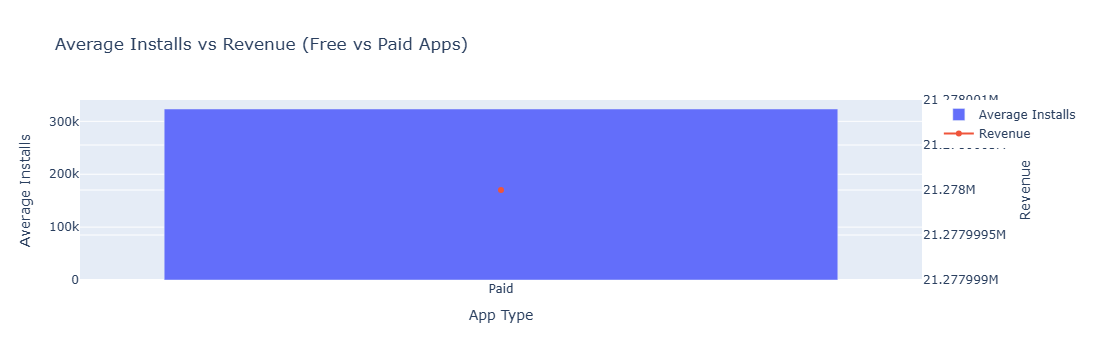

In [1]:
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime

# Load Dataset
df = pd.read_csv(r"C:\Users\Harshitha.M\Downloads\Play Store Data (1).csv")

# Remove duplicates
df = df.drop_duplicates()

# Convert Rating
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Convert Reviews
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

# Clean Installs
df["Installs"] = df["Installs"].astype(str)
df["Installs"] = df["Installs"].str.replace(",", "", regex=False)
df["Installs"] = df["Installs"].str.replace("+", "", regex=False)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Clean Price
df["Price"] = df["Price"].astype(str)
df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Convert Size to MB
def convert_size(size):
    size = str(size)
    if "M" in size:
        return float(size.replace("M", ""))
    elif "k" in size:
        return float(size.replace("k", "")) / 1024
    else:
        return None

df["Size"] = df["Size"].apply(convert_size)

# Revenue
df["Revenue"] = df["Price"] * df["Installs"]

# Filters
filtered_df = df[
    (df["Installs"] > 10000) &
    (df["Revenue"] > 10000) &
    (df["Rating"] > 4.0) &
    (df["Size"] > 15) &
    (df["Content Rating"] == "Everyone") &
    (df["App"].str.len() <= 30)
]

# Top 3 Categories
top_categories = (
    filtered_df.groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

filtered_df = filtered_df[
    filtered_df["Category"].isin(top_categories)
]

# Average Installs and Revenue
result = (
    filtered_df.groupby("Type")
    .agg(
        Average_Installs=("Installs", "mean"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

# Current Time
current_hour = 13
# Change to:
# current_hour = datetime.now().hour
# before submitting

if 13 <= current_hour < 14:

    fig = go.Figure()

    fig.add_trace(
        go.Bar(
            x=result["Type"],
            y=result["Average_Installs"],
            name="Average Installs"
        )
    )

    fig.add_trace(
        go.Scatter(
            x=result["Type"],
            y=result["Revenue"],
            mode="lines+markers",
            name="Revenue",
            yaxis="y2"
        )
    )

    fig.update_layout(
        title="Average Installs vs Revenue (Free vs Paid Apps)",
        xaxis_title="App Type",
        yaxis=dict(title="Average Installs"),
        yaxis2=dict(
            title="Revenue",
            overlaying="y",
            side="right"
        )
    )

    fig.show()

else:
    print("This graph is available only between 1 PM and 2 PM IST.")